# ANN for Regression

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

In [2]:
df=pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
# AT => temperature
# V => vacuum
# AP => pressure
# RH => humidity

# PE => produced energy

In [4]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [5]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
df.shape

(9568, 5)

In [9]:
scaler=StandardScaler()
X_train_Scaled=scaler.fit_transform(X_train)
X_test_Scaled=scaler.transform(X_test)

In [10]:
X_test_Scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]])

In [11]:
import torch
import torch.nn as nn

In [12]:
x_train_tensor=torch.tensor(X_train_Scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)


x_test_tensor=torch.tensor(X_test_Scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [13]:
type(X_train_Scaled)
type(y_train)

pandas.core.series.Series

In [14]:
y_test_tensor
type(y_test_tensor)

torch.Tensor

In [15]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(x_train_tensor,y_train_tensor) #input and output features
test_dataset=TensorDataset(x_test_tensor,y_test_tensor) 

In [16]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)


## Deep Learning


### Building ANN Model

In [17]:
#Define Aour ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            # 2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),

            # Output Layer
            nn.Linear(6,1),

 
        )

    def forward(self,x):
        return self.model(x)

In [18]:
model=ANN()

In [19]:
# Loss ,Optimizer

import torch.optim as optim

crietrion= nn.MSELoss()
optimizer= optim.Adam(model.parameters())

### Train the ANN

In [20]:
train_losses=[]
valid_losses=[]

best_val_loss = float("inf")

epochs=100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch

    for xb,yb in train_loader:
        # XB = features of 1 batch
        # YB = labels of 1 batch

        optimizer.zero_grad() # use for fresh gardient
        
        output=model(xb) # Forward Prop.... Predicted Outputs of this Batch

        loss = crietrion(output,yb) # compute loss
        loss.backward() # Back prop.... compute gradient
        optimizer.step() # params update

        running_loss+=loss.item() #loss is a tensor => py float
    
    epoch_train_loss=running_loss/len(train_loader) #Avg loss per batch
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss=0.0

    with torch.no_grad():  # no gradients compute
        for xb,yb in test_loader:
            outputs=model(xb)
            loss = crietrion(outputs,yb)
            running_val_loss+=loss

    epoch_val_loss=running_val_loss/len(test_loader)

    valid_losses.append(epoch_val_loss)
    

    print(f"Epoch {epoch+1}/{epoch} ==> Train Loss = {epoch_train_loss} & Valid Loss = {epoch_val_loss}")


    if epoch_val_loss<best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")  # .pt or .pth




Epoch 1/0 ==> Train Loss = 206332.90494791666 & Valid Loss = 204216.578125
Epoch 2/1 ==> Train Loss = 196511.11770833333 & Valid Loss = 183776.203125
Epoch 3/2 ==> Train Loss = 162061.31614583332 & Valid Loss = 135765.03125
Epoch 4/3 ==> Train Loss = 106006.59420572917 & Valid Loss = 76796.4921875
Epoch 5/4 ==> Train Loss = 53990.87010091146 & Valid Loss = 36285.3046875
Epoch 6/5 ==> Train Loss = 26550.9778523763 & Valid Loss = 20403.8984375
Epoch 7/6 ==> Train Loss = 16847.56563313802 & Valid Loss = 14704.517578125
Epoch 8/7 ==> Train Loss = 12744.501251220703 & Valid Loss = 11384.537109375
Epoch 9/8 ==> Train Loss = 9888.650266520182 & Valid Loss = 8825.34765625
Epoch 10/9 ==> Train Loss = 7601.182781982422 & Valid Loss = 6754.1728515625
Epoch 11/10 ==> Train Loss = 5734.296357218424 & Valid Loss = 5102.62353515625
Epoch 12/11 ==> Train Loss = 4295.600258382162 & Valid Loss = 3840.16064453125
Epoch 13/12 ==> Train Loss = 3199.1437672932943 & Valid Loss = 2903.180419921875
Epoch 14/13

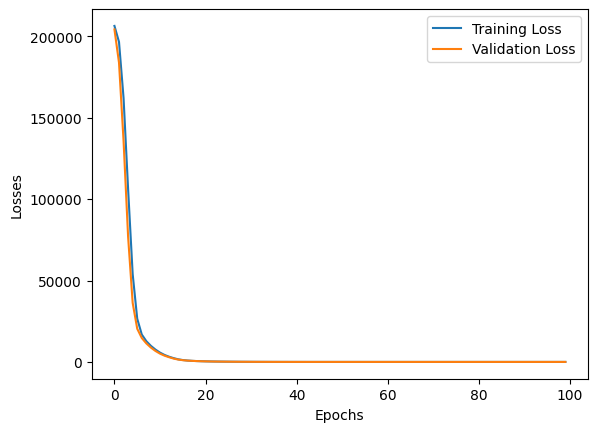

In [21]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": valid_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

### Loading the best model


In [22]:
model.load_state_dict(torch.load("best_model.pt"))


<All keys matched successfully>

### Evaluation

In [24]:
# Evaluate our model

model.eval()
with torch.no_grad():
    train_preds=model(x_train_tensor)
    test_preds=model(x_test_tensor)

    train_MSE_loss=crietrion(train_preds,y_train_tensor)
    test_MSE_loss=crietrion(test_preds,y_test_tensor)


print("Training MSE: ",train_MSE_loss.item())
print("Testing MSE: ",test_MSE_loss.item())

Training MSE:  19.022846221923828
Testing MSE:  17.49869728088379


In [25]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.938846570245683


In [26]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,436.163361,433.27
1,436.875244,438.16
2,460.493378,458.42
3,476.420135,480.82
4,438.732239,441.41
...,...,...
1909,451.067444,456.70
1910,434.124786,438.04
1911,467.593414,467.80
1912,433.801575,437.14
